<a href="https://colab.research.google.com/github/simsim000/rob/blob/main/exp5_Robotics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

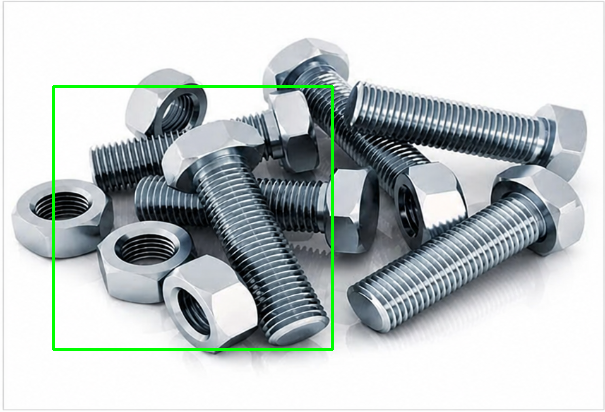

In [2]:
import cv2
import numpy as np
import requests
from google.colab.patches import cv2_imshow

def url_to_image(url):
    # Standard header to avoid being blocked
    resp = requests.get(url)
    image = np.asarray(bytearray(resp.content), dtype="uint8")
    image = cv2.imdecode(image, cv2.IMREAD_COLOR)
    return image


scene_url = 'https://drive.google.com/uc?export=download&id=1su1Q2wJ96cBE87QH5YZu3SMMTMNx9Bwt'
template_url = 'https://drive.google.com/uc?export=download&id=1MmKVi0UMKy_CQ8PxO9M7e44rZeeKYORd'

img = url_to_image(scene_url)
template_raw = url_to_image(template_url)

if img is None or template_raw is None:
    print("Error: Could not download images. Ensure the Drive files are set to 'Anyone with the link'.")
    exit()

# Convert template to grayscale for matching
template = cv2.cvtColor(template_raw, cv2.COLOR_BGR2GRAY)
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

w, h = template.shape[::-1]

result = cv2.matchTemplate(gray_img, template, cv2.TM_CCOEFF_NORMED)
_, max_val, _, max_loc = cv2.minMaxLoc(result)

top_left = max_loc
bottom_right = (top_left[0] + w, top_left[1] + h)

cv2.rectangle(img, top_left, bottom_right, (0, 255, 0), 2)
cv2_imshow(img)